#**Scenario:** Predict Credit Card Fraud using **SVM**, **KNN**, and **Naive Bayes**

###**Dataset Description**
The datasets contains transactions made by credit cards in September 2013 by european cardholders.

Presents transactions that occurred in two days, where we have **492** frauds out of **284,807** transactions.

- **Time** - Number of seconds elapsed between this transaction and the first transaction in the dataset
- **V1-V28** - Encrpted attributes (or columns) to protect user identities and sensitive features (v1-v28)
- **Amount** - Transaction Amount
- **Class** - **1** for fraudulent transactions, **0** otherwise

In [ ]:
#Downloading the data set from Dropbox
#Please run this cell in Google Colab

!wget https://www.dropbox.com/s/oey6vxdcc4fiemv/creditcard.csv

In [2]:
# import pandas as pd
# df = pd.read_csv('creditcard.csv')
# print(df.shape)
# df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


####**Importing Required Libraries**

In [3]:
!pip install ydata-profiling

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
sns.set()


import warnings
warnings.filterwarnings("ignore")
import os


print('Libraries Imported')

Libraries Imported


In [5]:
# df = pd.read_csv('creditcard.csv')
df = pd.read_csv('creditcard2.csv')
print(df.shape)
df.head()

(2807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [6]:
df.Class.value_counts()

,count
Class,
0,2315
1,492


###**Exploratory Data Analysis**

#### Generate a Data Report using Pandas Profiling

In [7]:
import ydata_profiling
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html') #Generating a Data Report

# This will take a few minutes to run

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Please refer to the HTML file created by the name of **output.html**

In [ ]:
ProfileReport(df).to_notebook_iframe()

###**Data Manipulation**

**RobustScaler:** Unlike the previous scalers, the
centering and scaling statistics of RobustScaler is based on percentiles and are therefore not influenced by a few number of very large marginal outliers. Consequently, the resulting range of the transformed feature values is larger than for the previous scalers and, more importantly, are approximately similar: for both features most of the transformed values lie in a [-2, 3] range

In [ ]:
df['Amount'].values.shape

In [9]:
x = df['Amount'].values.reshape(-1,1)
x.shape

(2807, 1)

In [10]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

#Fit_Transform the scaled_amount and scaled_time columns in the data set and dropping the Original Time and Amount Column from the data set

df['scaled_amount'] = rs.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rs.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time', 'Amount'], axis=1, inplace=True) #Dropping the Original Time and Amount Column from the data set

In [11]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'scaled_amount', 'scaled_time'],
      dtype='object')

In [12]:
df = df[['scaled_amount', 'scaled_time','V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class']]
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-0.249922,-0.018253,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,...,-0.058040,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0
1,-0.207313,-0.387894,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,...,-0.081298,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,0
2,-0.072510,-0.334921,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,...,0.065716,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,0
3,0.450757,0.377186,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,...,-0.169706,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,0
4,-0.259391,0.074274,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,...,-0.282777,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0


In [ ]:
# scaled_amount = df['scaled_amount']
# scaled_time = df['scaled_time']
# df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
# df.insert(0, 'scaled_amount', scaled_amount)
# df.insert(0, 'scaled_time', scaled_time)
# df.head()

In [14]:

from sklearn.model_selection import train_test_split #Importing the train_test_split from sklearn library
x = df.drop('Class', axis=1)
y = df['Class']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
print('x_train:',x_train.shape)
print('y_train:',y_train.shape)
print('x_test:',x_test.shape)
print('y_test:',y_test.shape)
# x = np.array(df.iloc[:, df.columns != 'Class']) #Predictors
# y = np.array(df.iloc[:, df.columns == 'Class']) #Target Column
# x_train, x_test, y_train, y_test = holdout(x, y, test_size=0.2, random_state=0) #Splitting the data set into training and testing set

x_train: (2245, 30)
y_train: (2245,)
x_test: (562, 30)
y_test: (562,)


###**Model Building**

####**SVM**

**Baseline Modelling**

In [15]:
from sklearn import svm
# Create and train a Linear SVM model
msvm = svm.LinearSVC(random_state=20)
msvm.fit(x_train, y_train)
predicted = msvm.predict(x_test)

In [16]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predicted)

array([[449,   2],
       [ 20,  91]])

In [17]:
from sklearn.metrics import  accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
# Metrics
svm_roc=roc_auc_score(y_test, predicted)
svm_acc = accuracy_score(y_test, predicted)
svm_prec = precision_score(y_test, predicted)
svm_rec = recall_score(y_test, predicted)
svm_f1 = f1_score(y_test, predicted)
print('roc:',svm_roc)
print('accuracy:',svm_acc)
print('precision:',svm_prec)
print('recall:',svm_rec)
print('f1:',svm_f1)

roc: 0.9076926150096882
accuracy: 0.9608540925266904
precision: 0.978494623655914
recall: 0.8198198198198198
f1: 0.8921568627450981


####**KNN**

In [ ]:
df.head()

In [18]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3,metric='euclidean')  # here k=3
model.fit(x_train,y_train)
y_pred2=model.predict(x_test)

In [19]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred2))

[[449   2]
 [ 17  94]]


[[55636  1225]
 [   15    86]]

In [21]:
from sklearn.metrics import  accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report

knn_roc=roc_auc_score(y_test, y_pred2)
knn_acc = accuracy_score(y_test, y_pred2)
knn_prec = precision_score(y_test, y_pred2)
knn_rec = recall_score(y_test, y_pred2)
knn_f1 = f1_score(y_test, y_pred2)
print('roc:',knn_roc)
print('accuracy:',knn_acc)
print('precision:',knn_prec)
print('recall:',knn_rec)
print('f1:',knn_f1)

roc: 0.9212061285232017
accuracy: 0.9661921708185054
precision: 0.9791666666666666
recall: 0.8468468468468469
f1: 0.9082125603864735


In [22]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       451
           1       0.98      0.85      0.91       111

    accuracy                           0.97       562
   macro avg       0.97      0.92      0.94       562
weighted avg       0.97      0.97      0.97       562



- **macro avg**
 - This function computes f1 for each label, and returns the average without considering the proportion for each label in the dataset

- **weighted avg**
 - This function computes f1 for each label, and returns the average considering the proportion for each label in the dataset

**How to choose the Value of K in KNN?**

Minimum error:- 0.033807829181494664 at K = 0


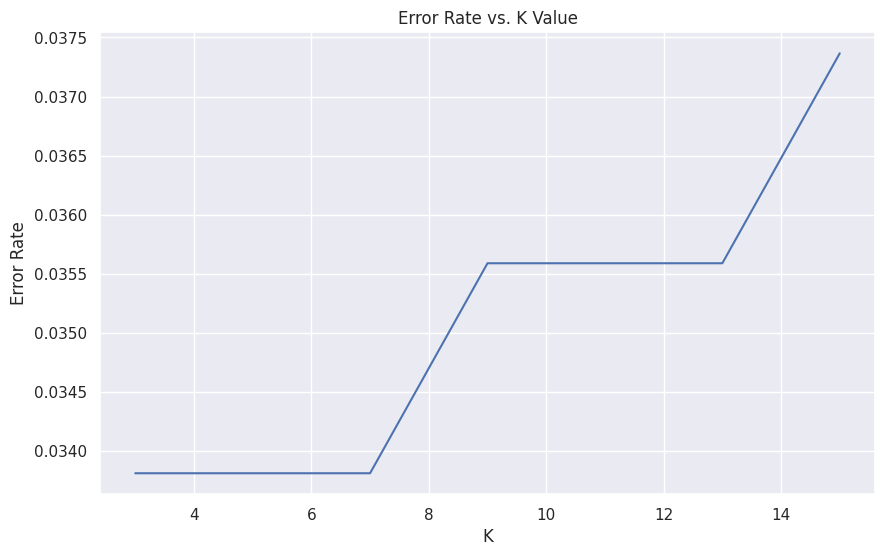

In [24]:
#This cell will take around 30 to 45 mins to execute

error_rate = []
for i in range(3,16,2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(3,16,2),error_rate)

plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

**Re-train the KNN Model with the optimal value of K**

In [25]:
model=KNeighborsClassifier(n_neighbors=7,metric='euclidean')  # here k=7
model.fit(x_train,y_train)

y_pred2=model.predict(x_test)

print(confusion_matrix(y_test,y_pred2))

[[450   1]
 [ 18  93]]


####**Naive Bayes**

In [26]:
from sklearn.naive_bayes import GaussianNB

#Create and Train a Gaussian Classifier
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_pred = gnb.predict(x_test)

In [27]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[444   7]
 [ 19  92]]


In [28]:
from sklearn.metrics import  accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

roc=roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print('roc:',roc)
print('accuracy:',acc)
print('precision:',prec)
print('recall:',rec)
print('f1:',f1)

roc: 0.9066538822636384
accuracy: 0.9537366548042705
precision: 0.9292929292929293
recall: 0.8288288288288288
f1: 0.8761904761904762


###**Model Evaluation**

- **Precision:**
  - What percebtage of positive predictions made were correct? This is **Precision**
  - No. of True Positives divided by the no. of True Positives plus the No. of False Positives

- **Recall:** Ratio of True Positives to all the positives in your Dataset

- **When to use Precision & Recall:**
 - In the credit card fraud detection task, lets say we modify the model slightly, and identify a single transaction correctly as fraud.

 - Now, our precision will be 1.0 (no false positives) but our recall will be very low because we will still have many false negatives.

 - If we go to the other extreme and classify all transactions as fraud, we will have a recall of 1.0 — we’ll catch every fraud transaction — but our precision will be very low and we’ll misclassify many legit transactions. In other words, as we increase precision we decrease recall and vice-versa.

- **F1-Score:**
 F1 Score is the weighted average of Precision and Recall. F1 is usually more useful than accuracy, especially when we have an uneven class distribution

 - **When to use F1-Score:**
   - Useful when you have data with imbalance classes
   - Let us say, we have a model with a precision of 1, and recall of 0 which gives a simple average as 0.5 and an F1 score of 0
   - If one of the parameters is low, the second one no longer matters in the F1 score
   - The F1 score favors classifiers that have similar precision and recall
   - F1 score is a better measure to use if you are seeking a balance between Precision and Recall

- **roc_auc_score**
 - roc_auc_score always runs from 0 to 1, and is sorting predictive possibilities. 0.5 is the baseline for random guessing
 - This metric shows how good at ranking predictions our model is
  
   When to/ not to use it?
    - Should not use it when your data is heavily imbalanced
    - Should use it when you care equally about positive and negative classes



In [29]:
results = pd.DataFrame([['Naive Bayes Classifier', acc,prec,rec, f1,roc],
                        ['Support Vector Machine', svm_acc, svm_prec, svm_rec, svm_f1, svm_roc],
                        ['K- Nearest Neigbor', knn_acc, knn_prec, knn_rec, knn_f1, knn_roc]
                        ],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score','ROC'])
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC
0,Naive Bayes Classifier,0.953737,0.929293,0.828829,0.876190,0.906654
1,Support Vector Machine,0.960854,0.978495,0.819820,0.892157,0.907693
2,K- Nearest Neigbor,0.966192,0.979167,0.846847,0.908213,0.921206


observation:



###**Model Optimization: GridSearchCV**

**SVM Hyperparameters:**

- **Gamma**
 - Used with non-linear SVM. Commonly used non-linear kernel is the Radial Basis Function (RBF)
 - Gamma parameter of RBF controls the distance of the influence of a single training point
 - Low values of gamma indicate a large similarity radius which results in more points being grouped together
 - For high values of gamma, the points need to be very close to each other in order to be considered in the same group (or class)
 - Models with very large gamma values tend to overfit.

- **C**
 - Adds a penalty for each misclassified data point
 - If c is small, the penalty for misclassified points is low so a decision boundary with a large margin is chosen at the expense of a greater number of misclassifications
 - If c is large, SVM tries to minimize the number of misclassified examples due to high penalty which results in a decision boundary with a smaller margin
 - Penalty is not same for all misclassified examples
 - It is directly proportional to the distance to decision boundary

**NOTE:** If you want to learn more about SVM Hyper-parameters, [**Click Here!**](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

In [30]:
#GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
# param_grid = {'C': [0.1, 1, 10, 100, 1000],
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
# 			'kernel': ['rbf']}
param_grid = {'C': [0.1, 1, 10],
			'gamma': ['scale', 'auto'],
			'kernel': ['rbf']}

svc_grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3, cv=2)

svc_grid.fit(x_train, y_train)


Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV 1/2] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.964 total time=   0.0s
[CV 2/2] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.966 total time=   0.0s
[CV 1/2] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.965 total time=   0.1s
[CV 2/2] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.960 total time=   0.1s
[CV 1/2] END ......C=1, gamma=scale, kernel=rbf;, score=0.970 total time=   0.0s
[CV 2/2] END ......C=1, gamma=scale, kernel=rbf;, score=0.973 total time=   0.0s
[CV 1/2] END .......C=1, gamma=auto, kernel=rbf;, score=0.965 total time=   0.0s
[CV 2/2] END .......C=1, gamma=auto, kernel=rbf;, score=0.972 total time=   0.0s
[CV 1/2] END .....C=10, gamma=scale, kernel=rbf;, score=0.970 total time=   0.0s
[CV 2/2] END .....C=10, gamma=scale, kernel=rbf;, score=0.980 total time=   0.0s
[CV 1/2] END ......C=10, gamma=auto, kernel=rbf;, score=0.972 total time=   0.1s
[CV 2/2] END ......C=10, gamma=auto, kernel=rbf;,

GridSearchCV(cv=2, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf']},
             verbose=3)

In [31]:
print('Best Parameters:',svc_grid.best_params_, 'Best Estimator:',svc_grid.best_estimator_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} Best Estimator: SVC(C=10)


In [32]:
grid_predictions = svc_grid.predict(x_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,grid_predictions))
#print(classification_report(y_test, grid_predictions))

[[448   3]
 [ 17  94]]


In [33]:
grid_roc=roc_auc_score(y_test, grid_predictions)
grid_acc = accuracy_score(y_test, grid_predictions)
grid_prec = precision_score(y_test, grid_predictions)
grid_rec = recall_score(y_test, grid_predictions)
grid_f1 = f1_score(y_test, grid_predictions)
print('roc:',grid_roc)
print('accuracy:',grid_acc)
print('precision:',grid_prec)
print('recall:',grid_rec)
print('f1:',grid_f1)

roc: 0.9200974810730909
accuracy: 0.9644128113879004
precision: 0.9690721649484536
recall: 0.8468468468468469
f1: 0.9038461538461539


In [36]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC
0,Naive Bayes Classifier,0.953737,0.929293,0.828829,0.876190,0.906654
1,Support Vector Machine,0.960854,0.978495,0.819820,0.892157,0.907693
2,K- Nearest Neigbor,0.966192,0.979167,0.846847,0.908213,0.921206


In [34]:
df2 = {'Model': 'SVC With GridSearchCV', 'Accuracy': grid_acc, 'Precision': grid_prec, 'Recall': grid_rec, 'F1 Score': grid_f1, 'ROC': grid_roc}
results = results.append(df2, ignore_index = True)
results

AttributeError: 'DataFrame' object has no attribute 'append'

###**Dealing with Imbalanced Classes: Re-sampling the data set**

Two methods to create a balanced dataset out of an imbalanced one are:

- **Under-Sampling:**  
 - Balances the data by reducing the size of the majority class
 - Used when quantity of data is sufficient
 - By keeping all samples in the minority class and randomly selecting an equal number of samples in the majority class, a balanced new dataset can be made

- **Over-Sampling:**
 - Balances the data by increasing the size of the minority class
 - New minority class samples are generated by using **SMOTE** (**Synthetic Minority Over-Sampling Technique**)

**Oversampling:**
Using the resampling module from Scikit-Learn to randomly replicate samples from the minority class

In [40]:
df = pd.read_csv('/content/creditcard2.csv')
print(df.shape)
df.head()

(2807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [42]:
df.Class.value_counts()

,count
Class,
0,2315
1,492


In [43]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

not_fraud = df[df.Class==0]
fraud = df[df.Class==1]
not_fraud.shape, fraud.shape

((2315, 31), (492, 31))

In [44]:
fraud_upsampled = resample(fraud,
                          replace=True, # sample with replacement
                          n_samples=len(not_fraud), # match number in majority class
                          random_state=27) # reproducible results

fraud_upsampled.Class.value_counts()


,count
Class,
1,2315


In [49]:
upsampled = pd.concat([not_fraud, fraud_upsampled])
upsampled.Class.value_counts()

,count
Class,
0,2315
1,2315


In [50]:
upsampled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [53]:
y = upsampled.Class
X = upsampled.drop('Class', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('x_train:',X_train.shape)
print('y_train:',y_train.shape)
print('x_test:',X_test.shape)
print('y_test:',y_test.shape)
# X = pd.concat([X_train, y_train], axis=1)

x_train: (3704, 30)
y_train: (3704,)
x_test: (926, 30)
y_test: (926,)


**SVM**

In [54]:
from sklearn import svm
from sklearn.metrics import accuracy_score


svm_clf = svm.LinearSVC(random_state=20).fit(X_train, y_train)

predicted = svm_clf.predict(X_test)

# Checking the Model Accuracy
score=accuracy_score(y_test,predicted)
print("Your Model Accuracy is", score)

Your Model Accuracy is 0.9362850971922246


In [55]:
# Checking accuracy
print('Accuracy Score:',accuracy_score(y_test, predicted))

print(classification_report(y_test, predicted))

Accuracy Score: 0.9362850971922246
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       471
           1       0.98      0.89      0.93       455

    accuracy                           0.94       926
   macro avg       0.94      0.94      0.94       926
weighted avg       0.94      0.94      0.94       926



In [56]:
print(confusion_matrix(y_test, predicted))

[[463   8]
 [ 51 404]]


**Under-sampling**

In [ ]:
# Downsample Majority

not_fraud_downsampled = resample(not_fraud,
                                replace = False, # sample without replacement
                                n_samples = len(fraud), # match minority n
                                random_state = 42) # reproducible results

# Combine Minority and Downsampled Majority

downsampled = pd.concat([not_fraud_downsampled, fraud])

downsampled.Class.value_counts()

**SVM**

In [ ]:
y_train = downsampled.Class
X_train = downsampled.drop('Class', axis=1)

undersampled = svm.LinearSVC(random_state=20).fit(X_train, y_train)

undersampled_pred = undersampled.predict(X_test)

# Checking accuracy
print('Accuracy Score:',accuracy_score(y_test, undersampled_pred))

print(classification_report(y_test, undersampled_pred))


**Ovsersampling Using [imblearn's](https://imbalanced-learn.readthedocs.io/en/stable/index.html) SMOTE**

**SMOTE**(Synthetic Minority Oversampling Technique)
- Most commonly used oversampling methods to solve the imbalance problem
- Balances class distribution by randomly increasing minority class examples by replicating them
- Synthesises new minority instances between existing minority instances
- Generates the virtual training records by linear interpolation for the minority class
- These synthetic training records are generated by randomly selecting one or more of the k-nearest neighbors for each example in the minority class
- After the oversampling process, the data is reconstructed and several classification models can be applied for the processed data

**NOTE:**If you want to learn more about **SMOTE**, [**Click Here!**](https://imbalanced-learn.readthedocs.io/en/stable/generated/imblearn.over_sampling.SMOTE.html)


In [57]:
df.Class.value_counts()

,count
Class,
0,2315
1,492


In [59]:
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=27)

sm = SMOTE(random_state=27)
X_train, y_train = sm.fit_resample(X_train, y_train)

print('x_train:',X_train.shape)
print('y_train:',y_train.shape)
print('x_test:',X_test.shape)
print('y_test:',y_test.shape)


x_train: (3470, 30)
y_train: (3470,)
x_test: (702, 30)
y_test: (702,)


In [60]:
smote_svm = svm.LinearSVC(random_state=20).fit(X_train, y_train)

smote_pred = smote_svm.predict(X_test)

# Checking Accuracy, Recall, and F1-Score
print('Accuracy Score:',accuracy_score(y_test, smote_pred))
print(classification_report(y_test, smote_pred))



Accuracy Score: 0.9658119658119658
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       580
           1       0.94      0.86      0.90       122

    accuracy                           0.97       702
   macro avg       0.95      0.92      0.94       702
weighted avg       0.97      0.97      0.97       702



___
**Observations:**
- SMOTE outperformed other re-sampling techniques (over-sampling and under-sampling)
- Achieved a **Recall Score** of **0.81** (Best Value: **1** and Worst Value: **0**)
___